In [ ]:
MODEL = "comb_user"
COMB = "cat"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\RESEARCH\2024-2 지능정보시스템학회 추계학술대회\BAMF


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
from recsys import config, pipeline, trainer, evaluator, utils
import bamf

In [ ]:
PATH = f"./config/{MODEL}/{STRATEGY}_{COMB}.yaml"
cfg = config.builder.config_builder(PATH)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/{cfg.dataset}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.pipeline,
)

dataloaders, interactions, histories = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    histories=histories["user"],
    num_users=cfg.model.num_users,
    num_items=cfg.model.num_items,
    **cfg.model.params,
)

model = bamf.comb_user.Module(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.5588
	BEST EPOCH: 23


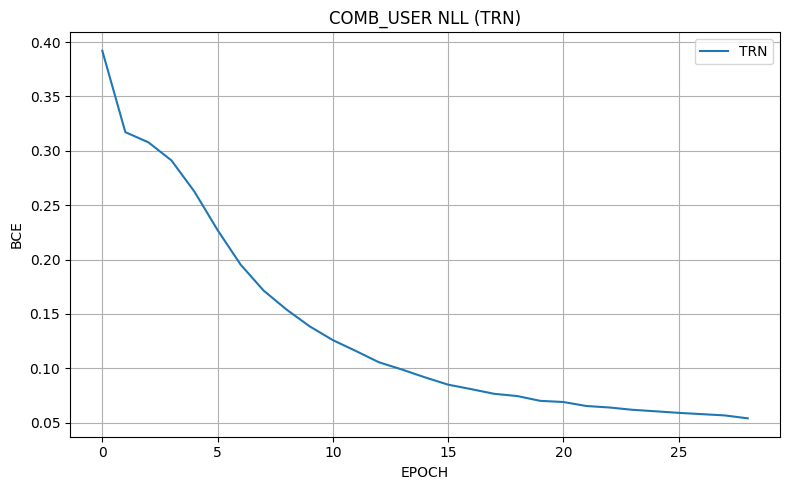

In [14]:
kwargs = dict(
    record=records["trn"]["nll"],
    label="TRN",
    criterion="BCE",
    title="COMB_USER NLL (TRN)",
)

utils.visualizer.main(**kwargs)

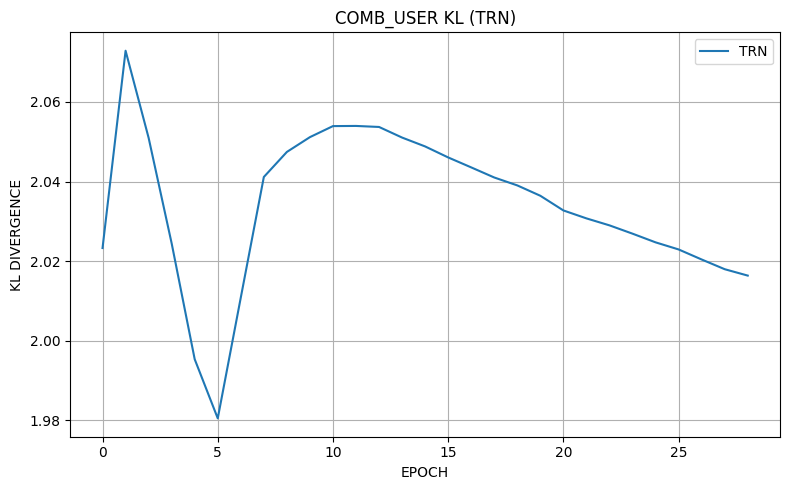

In [15]:
kwargs = dict(
    record=records["trn"]["kl"],
    label="TRN",
    criterion="KL DIVERGENCE",
    title="COMB_USER KL (TRN)",
)

utils.visualizer.main(**kwargs)

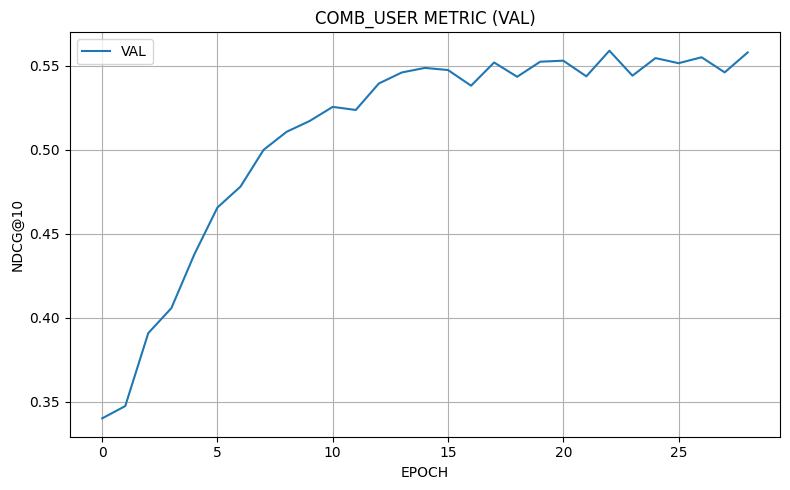

In [16]:
kwargs = dict(
    record=records["val"],
    label="VAL",
    criterion="NDCG@10",
    title="COMB_USER METRIC (VAL)",
)

utils.visualizer.main(**kwargs)

# Test

In [17]:
kwargs = dict(
    model=model,
    cfg=cfg.evaluator,
)

evaluator = evaluator.builder.evaluator_builder(**kwargs)

In [18]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 3941/3941 [00:39<00:00, 99.18it/s] 


In [19]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.891803,0.452131,0.322289,0.257280,0.537819
1,10,0.950820,0.351803,0.440003,0.310853,0.539223
2,15,0.973770,0.291913,0.514929,0.335258,0.547305
3,20,0.977049,0.255164,0.567309,0.350384,0.557372
4,25,0.988525,0.225770,0.605366,0.359432,0.564145
5,50,0.996721,0.155770,0.723134,0.385063,0.594729


# Save

In [20]:
PATH = f'./checkpoints/{cfg.model_cls}/{cfg.strategy}_{cfg.comb}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)